In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('val_feature.csv', sep=';')

In [3]:
df.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
0,597722,184,186,3061,1504047,1,02.12.2024,0.0,0.0,0.0
1,597722,184,187,3048,1504047,3,02.12.2024,0.0,0.0,0.0
2,597722,184,190,3046,1504047,6,02.12.2024,0.0,0.0,0.0
3,597722,184,191,8177,1504047,6,02.12.2024,0.0,0.0,0.0
4,597722,184,192,8178,1504047,5,02.12.2024,0.0,0.0,0.0


In [4]:
df.shape

(1293947, 10)

In [5]:
df.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
0,597722,184,186,3061,1504047,1,02.12.2024,0.0,0.0,0.0
1,597722,184,187,3048,1504047,3,02.12.2024,0.0,0.0,0.0
2,597722,184,190,3046,1504047,6,02.12.2024,0.0,0.0,0.0
3,597722,184,191,8177,1504047,6,02.12.2024,0.0,0.0,0.0
4,597722,184,192,8178,1504047,5,02.12.2024,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293947 entries, 0 to 1293946
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CC_ID             1293947 non-null  int64  
 1   SCORING_ID        1293947 non-null  int64  
 2   PARAM_ID          1293947 non-null  int64  
 3   VALUE_ID          1293947 non-null  int64  
 4   LOAN_ID           1293947 non-null  int64  
 5   SCORE_BALL        1293947 non-null  int64  
 6   APPLICATION_DATE  1293947 non-null  object 
 7   TARGET_30         1242881 non-null  float64
 8   TARGET_60         1242881 non-null  float64
 9   TARGET_90         1242881 non-null  float64
dtypes: float64(3), int64(6), object(1)
memory usage: 98.7+ MB


In [7]:
df[(df['TARGET_90'].isnull()) & (df['SCORING_ID'] == 727)].head(15)

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
17001,918391,727,11,10398,1574447,50,25.04.2025,NaN,NaN,NaN
17002,918391,727,34,10457,1574447,50,25.04.2025,NaN,NaN,NaN
17003,918391,727,186,10450,1574447,10,25.04.2025,NaN,NaN,NaN
17004,918391,727,187,10412,1574447,30,25.04.2025,NaN,NaN,NaN
17005,918391,727,188,11562,1574447,0,25.04.2025,NaN,NaN,NaN
17006,918391,727,189,10441,1574447,120,25.04.2025,NaN,NaN,NaN
17007,918391,727,190,10446,1574447,40,25.04.2025,NaN,NaN,NaN
17008,918391,727,191,10431,1574447,-80,25.04.2025,NaN,NaN,NaN
17009,918391,727,193,10434,1574447,80,25.04.2025,NaN,NaN,NaN
17010,918391,727,194,10424,1574447,0,25.04.2025,NaN,NaN,NaN


In [8]:
df['APPLICATION_DATE'] = pd.to_datetime(
    df['APPLICATION_DATE'],
    format='%d.%m.%Y'
)
df[df['TARGET_90'].isnull()]
df = df.dropna(subset=['TARGET_90'])

In [9]:
df.shape

(1242881, 10)

In [10]:
data = df.copy()

In [11]:
df.groupby('SCORING_ID')['APPLICATION_DATE'].agg({min, max})

C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\985070687.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby('SCORING_ID')['APPLICATION_DATE'].agg({min, max})
C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\985070687.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby('SCORING_ID')['APPLICATION_DATE'].agg({min, max})


,min,max
SCORING_ID,,
42,2022-07-19,2026-03-10
122,2022-10-17,2026-03-13
184,2023-01-06,2026-02-18
343,2024-02-09,2025-11-19
504,2024-06-19,2026-05-26
727,2025-01-22,2026-06-23


In [12]:
df = df[df['SCORING_ID'] == 727]

In [13]:
df.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
78583,1248818,727,204,11750,1604268,0,2025-08-01,0.0,0.0,0.0
78584,1248818,727,210,10406,1604268,130,2025-08-01,0.0,0.0,0.0
78585,1248818,727,227,11612,1604268,40,2025-08-01,0.0,0.0,0.0
78586,1248818,727,231,11564,1604268,50,2025-08-01,0.0,0.0,0.0
78587,1248818,727,232,11600,1604268,10,2025-08-01,0.0,0.0,0.0


In [14]:
df_score = (
    df.groupby('CC_ID')
      .agg(
          SCORE=('SCORE_BALL','sum'),
          TARGET=('TARGET_90','max')
      )
      .reset_index()
)

In [15]:
df_score = df_score[~df_score['SCORE'] < 0]

In [16]:
df_score.describe()

,CC_ID,SCORE,TARGET
count,1.903700e+04,19037.000000,19037.000000
mean,1.329707e+06,645.847140,0.012187
std,3.139133e+05,92.128292,0.109722
min,6.771190e+05,397.000000,0.000000
25%,1.080033e+06,577.000000,0.000000
50%,1.292100e+06,650.000000,0.000000
75%,1.541573e+06,717.000000,0.000000
max,2.471702e+06,920.000000,1.000000


In [17]:
from sklearn.linear_model import LogisticRegression

cal = LogisticRegression(
    solver='lbfgs',
    C=0.1,
    penalty='l2',
    max_iter=1000
)

cal.fit(
    df_score[['SCORE']],
    df_score['TARGET']
)

a = cal.intercept_[0]
b = cal.coef_[0][0]

print("Intercept =", a)
print("Slope =", b)

Intercept = 1.1878565820553755
Slope = -0.009162364837506426


C:\Users\sh.nabiyev\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
df_score['PD_CAL'] = cal.predict_proba(
    df_score[['SCORE']]
)[:,1]

In [19]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(
    df_score['TARGET'],
    -df_score['SCORE']
)

auc_pd = roc_auc_score(
    df_score['TARGET'],
    df_score['PD_CAL']
)

print(auc_score)
print(auc_pd)

0.7242951709468317
0.7242951709468317


In [20]:
from sklearn.metrics import log_loss

logloss = log_loss(
    df_score['TARGET'],
    df_score['PD_CAL']
)

print("LogLoss =", logloss)

LogLoss = 0.06201430115845899


                              DECILE    AVG_PD  OBSERVED_DR   CNT   BAD
0  (-0.00028400000000000007, 0.0029]  0.002243     0.001008  1984   2.0
1                  (0.0029, 0.00418]  0.003682     0.004649  2151  10.0
2                 (0.00418, 0.00535]  0.004854     0.004459  1794   8.0
3                 (0.00535, 0.00659]  0.006093     0.003346  1793   6.0
4                 (0.00659, 0.00843]  0.007647     0.006623  1963  13.0
5                  (0.00843, 0.0111]  0.009832     0.010269  2045  21.0
6                   (0.0111, 0.0145]  0.012863     0.019053  1837  35.0
7                   (0.0145, 0.0195]  0.017240     0.019681  1880  37.0
8                   (0.0195, 0.0279]  0.024106     0.021131  1751  37.0
9                   (0.0279, 0.0795]  0.036234     0.034258  1839  63.0


C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\394311140.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('DECILE')


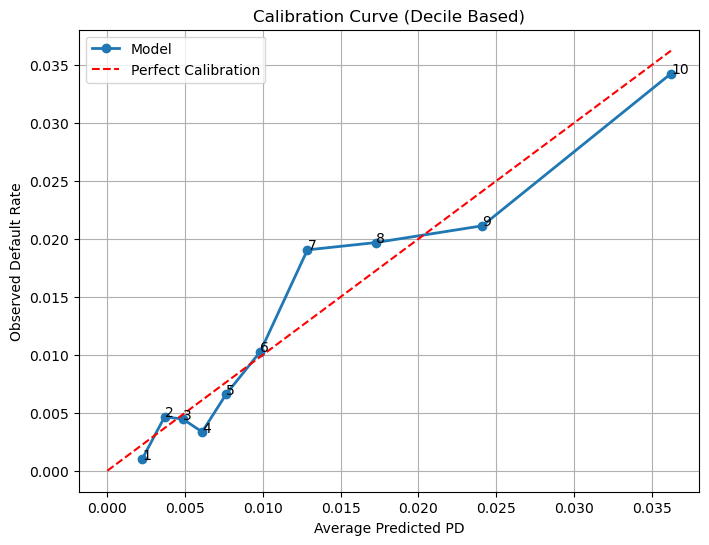

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PD bo'yicha 10 ta guruh
df_score['DECILE'] = pd.qcut(
    df_score['PD_CAL'],
    q=10,
    duplicates='drop'
)

# Har bir guruh uchun PD va haqiqiy DR
calibration_table = (
    df_score
    .groupby('DECILE')
    .agg(
        AVG_PD=('PD_CAL', 'mean'),
        OBSERVED_DR=('TARGET', 'mean'),
        CNT=('TARGET', 'count'),
        BAD=('TARGET', 'sum')
    )
    .reset_index()
)

print(calibration_table)

# Calibration Curve
plt.figure(figsize=(8,6))

plt.plot(
    calibration_table['AVG_PD'],
    calibration_table['OBSERVED_DR'],
    marker='o',
    linewidth=2,
    label='Model'
)

max_val = max(
    calibration_table['AVG_PD'].max(),
    calibration_table['OBSERVED_DR'].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    '--',
    color='red',
    label='Perfect Calibration'
)

# nuqtalarga qiymat yozish
for i, row in calibration_table.iterrows():
    plt.annotate(
        f"{i+1}",
        (row['AVG_PD'], row['OBSERVED_DR'])
    )

plt.xlabel('Average Predicted PD')
plt.ylabel('Observed Default Rate')
plt.title('Calibration Curve (Decile Based)')
plt.legend()
plt.grid(True)

plt.show()

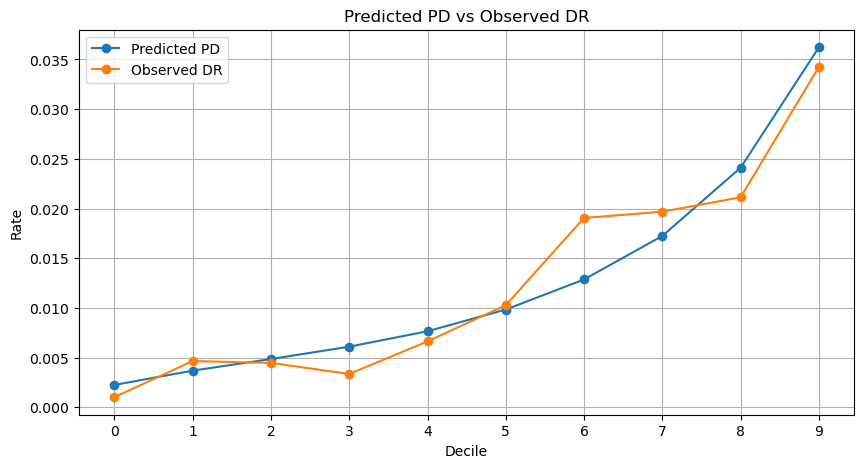

In [22]:
plt.figure(figsize=(10,5))

x = np.arange(len(calibration_table))

plt.plot(
    x,
    calibration_table['AVG_PD'],
    marker='o',
    label='Predicted PD'
)

plt.plot(
    x,
    calibration_table['OBSERVED_DR'],
    marker='o',
    label='Observed DR'
)

plt.xticks(x)

plt.title('Predicted PD vs Observed DR')
plt.xlabel('Decile')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
df_score['PD'] = cal.predict_proba(df_score[['SCORE']])[:,1]

In [24]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

print("LogLoss:", log_loss(df_score['TARGET'], df_score['PD']))
print("Brier:", brier_score_loss(df_score['TARGET'], df_score['PD']))
print("AUC:", roc_auc_score(df_score['TARGET'], df_score['PD']))

LogLoss: 0.06201430115845899
Brier: 0.011945474366829491
AUC: 0.7242951709468317


In [25]:
df_score_final = df_score[['CC_ID','SCORE','TARGET','PD']]

In [26]:
df_score_final.head()

,CC_ID,SCORE,TARGET,PD
0,677119,860,0.0,0.001240
1,677131,760,0.0,0.003093
2,766406,820,0.0,0.001787
3,767469,740,0.0,0.003713
4,783013,870,0.0,0.001131


In [27]:
df_score_final[df_score_final['TARGET'] == 1].sort_values('SCORE', ascending=True)

,CC_ID,SCORE,TARGET,PD
984,916134,460,1.0,0.046228
15221,1585058,460,1.0,0.046228
11126,1373857,467,1.0,0.043481
3943,1037918,467,1.0,0.043481
13142,1480149,467,1.0,0.043481
347,884613,467,1.0,0.043481
7014,1177052,467,1.0,0.043481
3511,1020036,470,1.0,0.042352
14912,1569983,470,1.0,0.042352
5510,1109804,470,1.0,0.042352


In [28]:
df_score['BIN'] = pd.qcut(df_score['SCORE'], 10)

df_score.groupby('BIN').agg(
    avg_score=('SCORE','mean'),
    bad_rate=('TARGET','mean'),
    cnt=('TARGET','count')
)

C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\3346719955.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_score.groupby('BIN').agg(


,avg_score,bad_rate,cnt
BIN,,,
"(396.999, 517.0]",492.025157,0.030963,2067
"(517.0, 557.0]",539.438567,0.023322,1758
"(557.0, 590.0]",575.853520,0.019669,1932
"(590.0, 620.0]",608.799579,0.018411,1901
"(620.0, 650.0]",638.726660,0.009625,2078
"(650.0, 677.0]",666.290486,0.005061,1976
"(677.0, 700.0]",690.679931,0.004037,1734
"(700.0, 727.0]",715.905534,0.003913,1789
"(727.0, 767.0]",746.713450,0.004386,2052


In [29]:
from scipy.stats import ks_2samp

good = df_score.loc[df_score['TARGET']==0,'SCORE']
bad = df_score.loc[df_score['TARGET']==1,'SCORE']

ks = ks_2samp(good, bad).statistic
print(ks)

0.3698764085120428


In [30]:
df_score['decile'] = pd.qcut(df_score['PD'], 10)

df_score.groupby('decile')['TARGET'].mean()

C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\1173209849.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_score.groupby('decile')['TARGET'].mean()


decile
(-0.00028400000000000007, 0.0029]    0.001008
(0.0029, 0.00418]                    0.004649
(0.00418, 0.00535]                   0.004459
(0.00535, 0.00659]                   0.003346
(0.00659, 0.00843]                   0.006623
(0.00843, 0.0111]                    0.010269
(0.0111, 0.0145]                     0.019053
(0.0145, 0.0195]                     0.019681
(0.0195, 0.0279]                     0.021131
(0.0279, 0.0795]                     0.034258
Name: TARGET, dtype: float64

In [31]:
import pandas as pd
import numpy as np

# 1. Decile yaratish (PD bo‘yicha)
df_score['DECILE'] = pd.qcut(
    df_score['PD'],
    q=10,
    duplicates='drop'
)

# 2. Risk table
decile_table = (
    df_score
    .groupby('DECILE')
    .agg(
        COUNT=('TARGET', 'count'),
        BAD=('TARGET', 'sum'),
        BAD_RATE=('TARGET', 'mean'),
        AVG_PD=('PD', 'mean'),
        MIN_PD=('PD', 'min'),
        MAX_PD=('PD', 'max')
    )
    .reset_index()
)

decile_table['GOOD'] = decile_table['COUNT'] - decile_table['BAD']

decile_table

C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\1727686634.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('DECILE')


,DECILE,COUNT,BAD,BAD_RATE,AVG_PD,MIN_PD,MAX_PD,GOOD
0,"(-0.00028400000000000007, 0.0029]",1984,2.0,0.001008,0.002243,0.000716,0.002901,1982.0
1,"(0.0029, 0.00418]",2151,10.0,0.004649,0.003682,0.003093,0.004180,2141.0
2,"(0.00418, 0.00535]",1794,8.0,0.004459,0.004854,0.004456,0.005347,1786.0
3,"(0.00535, 0.00659]",1793,6.0,0.003346,0.006093,0.005496,0.006593,1787.0
4,"(0.00659, 0.00843]",1963,13.0,0.006623,0.007647,0.006900,0.008428,1950.0
5,"(0.00843, 0.0111]",2045,21.0,0.010269,0.009832,0.008661,0.011065,2024.0
6,"(0.0111, 0.0145]",1837,35.0,0.019053,0.012863,0.011370,0.014515,1802.0
7,"(0.0145, 0.0195]",1880,37.0,0.019681,0.017240,0.014914,0.019540,1843.0
8,"(0.0195, 0.0279]",1751,37.0,0.021131,0.024106,0.020437,0.027947,1714.0
9,"(0.0279, 0.0795]",1839,63.0,0.034258,0.036234,0.029219,0.079468,1776.0


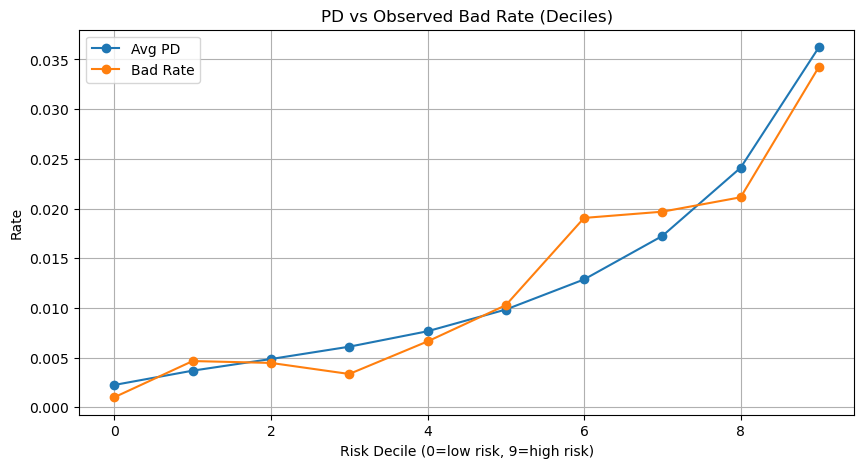

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

x = np.arange(len(decile_table))

plt.plot(x, decile_table['AVG_PD'], marker='o', label='Avg PD')
plt.plot(x, decile_table['BAD_RATE'], marker='o', label='Bad Rate')

plt.title("PD vs Observed Bad Rate (Deciles)")
plt.xlabel("Risk Decile (0=low risk, 9=high risk)")
plt.ylabel("Rate")
plt.legend()
plt.grid()
plt.show()

In [33]:
def risk_label(pd):
    if pd < 0.02:
        return "LOW RISK (Approve)"
    elif pd < 0.05:
        return "MEDIUM RISK (Review)"
    else:
        return "HIGH RISK (Reject)"

df_score['RISK_GROUP'] = df_score['PD'].apply(risk_label)

df_score['RISK_GROUP'].value_counts()

RISK_GROUP
LOW RISK (Approve)      15447
MEDIUM RISK (Review)     3566
HIGH RISK (Reject)         24
Name: count, dtype: int64

In [34]:
LGD = 0.45   # default assumption
EAD = 100000 # example loan amount

df_score['EL'] = df_score['PD'] * LGD * EAD

df_score[['PD','EL']].head()

,PD,EL
0,0.001240,55.779158
1,0.003093,139.181572
2,0.001787,80.426709
3,0.003713,167.068653
4,0.001131,50.901132


In [35]:
portfolio_summary = {
    "Avg PD": df_score['PD'].mean(),
    "Total Expected Loss": df_score['EL'].sum(),
    "Max PD": df_score['PD'].max(),
    "Min PD": df_score['PD'].min(),
    "Total Clients": len(df_score)
}

portfolio_summary

{'Avg PD': 0.01218690273487425,
 'Total Expected Loss': 10440093.03137105,
 'Max PD': 0.07946764012124947,
 'Min PD': 0.000715710333489174,
 'Total Clients': 19037}

In [36]:
report = pd.DataFrame({
    "Metric": ["LogLoss", "Brier", "AUC"],
    "Value": [
        log_loss(df_score['TARGET'], df_score['PD']),
        brier_score_loss(df_score['TARGET'], df_score['PD']),
        roc_auc_score(df_score['TARGET'], df_score['PD'])
    ]
})

report

,Metric,Value
0,LogLoss,0.062014
1,Brier,0.011945
2,AUC,0.724295


In [37]:
import pandas as pd

df_score['decile_score'] = pd.qcut(df_score['SCORE'], 10)

stability = df_score.groupby('decile_score').agg(
    COUNT=('TARGET','count'),
    BAD_RATE=('TARGET','mean'),
    AVG_SCORE=('SCORE','mean'),
    AVG_PD=('PD','mean')
).reset_index()

stability

C:\Users\sh.nabiyev\AppData\Local\Temp\ipykernel_5996\1164305205.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stability = df_score.groupby('decile_score').agg(


,decile_score,COUNT,BAD_RATE,AVG_SCORE,AVG_PD
0,"(396.999, 517.0]",2067,0.030963,492.025157,0.035320
1,"(517.0, 557.0]",1758,0.023322,539.438567,0.022997
2,"(557.0, 590.0]",1932,0.019669,575.853520,0.016555
3,"(590.0, 620.0]",1901,0.018411,608.799579,0.012281
4,"(620.0, 650.0]",2078,0.009625,638.726660,0.009364
5,"(650.0, 677.0]",1976,0.005061,666.290486,0.007283
6,"(677.0, 700.0]",1734,0.004037,690.679931,0.005833
7,"(700.0, 727.0]",1789,0.003913,715.905534,0.004635
8,"(727.0, 767.0]",2052,0.004386,746.713450,0.003512
9,"(767.0, 920.0]",1750,0.000571,803.001143,0.002155


In [38]:
df.head(2)

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90
78583,1248818,727,204,11750,1604268,0,2025-08-01,0.0,0.0,0.0
78584,1248818,727,210,10406,1604268,130,2025-08-01,0.0,0.0,0.0


In [39]:
df = df[~df['CC_ID'].isin([1021846, 1040067])]

In [40]:
bin_stats = (
    df.groupby(['PARAM_ID', 'VALUE_ID'])
      .agg(
          cnt=('TARGET_90', 'size'),
          bad=('TARGET_90', 'sum')
      )
      .reset_index()
)

bin_stats['good'] = (
    bin_stats['cnt']
    - bin_stats['bad']
)

In [41]:
total_good = bin_stats['good'].sum()
total_bad = bin_stats['bad'].sum()

In [42]:
bin_stats['good_pct'] = (
    bin_stats['good'] + 0.5
) / total_good

bin_stats['bad_pct'] = (
    bin_stats['bad'] + 0.5
) / total_bad

In [43]:
import numpy as np

bin_stats['WOE'] = np.log(
    bin_stats['good_pct']
    /
    bin_stats['bad_pct']
)

In [44]:
bin_stats['IV'] = (
    bin_stats['good_pct']
    - bin_stats['bad_pct']
) * bin_stats['WOE']

In [45]:
iv_table = (
    bin_stats
    .groupby('PARAM_ID')['IV']
    .sum()
    .reset_index()
    .sort_values('IV', ascending=False)
)

iv_table.head(20)

,PARAM_ID,IV
0,11,0.050061
1,34,0.047694
12,210,0.034567
3,187,0.022577
6,190,0.017933
18,253,0.017431
17,250,0.014676
13,227,0.009674
10,200,0.006523
9,194,0.004534


In [46]:
df_woe = df.merge(
    bin_stats[
        [
            'PARAM_ID',
            'VALUE_ID',
            'WOE'
        ]
    ],
    on=[
        'PARAM_ID',
        'VALUE_ID'
    ],
    how='left'
)

In [47]:
X = (
    df_woe
    .pivot_table(
        index='CC_ID',
        columns='PARAM_ID',
        values='WOE',
        aggfunc='first'
    )
    .reset_index()
)

In [48]:
target_df = (
    df_woe[
        ['CC_ID', 'TARGET_90']
    ]
    .drop_duplicates()
)

X = X.merge(
    target_df,
    on='CC_ID'
)

In [49]:
from sklearn.linear_model import LogisticRegression

X_train = X.drop(
    columns=[
        'CC_ID',
        'TARGET_90'
    ]
).fillna(0)

y_train = X['TARGET_90']

In [50]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
coef_df = pd.DataFrame({
    'PARAM_ID': X_train.columns,
    'BETA': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    'BETA',
    ascending=False
)

coef_df.head(20)

,PARAM_ID,BETA
9,194,0.814851
4,188,0.051211
8,193,0.051211
11,204,-0.019281
14,231,-0.019281
5,189,-0.197289
6,190,-0.354741
16,233,-0.469064
17,250,-0.470141
1,34,-0.494581


In [52]:
new_points = (
    bin_stats
    .merge(
        coef_df,
        on='PARAM_ID',
        how='left'
    )
)

In [53]:
PDO = 20

factor = PDO / np.log(2)

In [54]:
new_points['NEW_POINT'] = (
    -1
    * new_points['BETA']
    * new_points['WOE']
    * factor
)

In [55]:
new_points['NEW_POINT'] = (
    new_points['NEW_POINT']
    .round(0)
    .astype(int)
)

In [56]:
new_points[
    [
        'PARAM_ID',
        'VALUE_ID',
        'WOE',
        'BETA',
        'NEW_POINT'
    ]
]

,PARAM_ID,VALUE_ID,WOE,BETA,NEW_POINT
0,11,10397,-1.667308,-0.628987,-30
1,11,10398,0.108928,-0.628987,2
2,11,10399,0.979539,-0.628987,18
3,11,10400,1.259452,-0.628987,23
4,34,10453,-2.146570,-0.494581,-31
5,34,10454,-1.674745,-0.494581,-24
6,34,10455,-1.241972,-0.494581,-18
7,34,10456,-0.632843,-0.494581,-9
8,34,10457,0.215611,-0.494581,3
9,34,10458,0.871314,-0.494581,12


In [57]:
df_new = df.merge(
    new_points[
        [
            'PARAM_ID',
            'VALUE_ID',
            'NEW_POINT'
        ]
    ],
    on=[
        'PARAM_ID',
        'VALUE_ID'
    ],
    how='left'
)

In [58]:
df_new.head()

,CC_ID,SCORING_ID,PARAM_ID,VALUE_ID,LOAN_ID,SCORE_BALL,APPLICATION_DATE,TARGET_30,TARGET_60,TARGET_90,NEW_POINT
0,1248818,727,204,11750,1604268,0,2025-08-01,0.0,0.0,0.0,0
1,1248818,727,210,10406,1604268,130,2025-08-01,0.0,0.0,0.0,12
2,1248818,727,227,11612,1604268,40,2025-08-01,0.0,0.0,0.0,-17
3,1248818,727,231,11564,1604268,50,2025-08-01,0.0,0.0,0.0,0
4,1248818,727,232,11600,1604268,10,2025-08-01,0.0,0.0,0.0,1


In [59]:
client_score = (
    df_new
    .groupby('CC_ID')
    .agg(
        SCORE_NEW=('NEW_POINT', 'sum'),
        TARGET=('TARGET_90', 'max')
    )
    .reset_index()
)

In [60]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    client_score['TARGET'],
    client_score['SCORE_NEW']
)

gini = 2 * auc - 1

print('AUC:', auc)
print('GINI:', gini)

AUC: 0.13456092015146376
GINI: -0.7308781596970725


In [61]:
score_compare = (
    df_new
    .groupby('CC_ID')
    .agg(
        OLD_SCORE=('SCORE_BALL', 'sum'),
        NEW_SCORE=('NEW_POINT', 'sum'),
        TARGET=('TARGET_90', 'max')
    )
    .reset_index()
)

score_compare.head()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
0,677119,860,89,0.0
1,677131,760,32,0.0
2,766406,820,37,0.0
3,767469,740,70,0.0
4,783013,870,42,0.0


In [62]:
score_compare.describe()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
count,1.903700e+04,19037.000000,19037.000000,19037.000000
mean,1.329707e+06,645.847140,38.989757,0.012187
std,3.139133e+05,92.128292,42.546019,0.109722
min,6.771190e+05,397.000000,-124.000000,0.000000
25%,1.080033e+06,577.000000,12.000000,0.000000
50%,1.292100e+06,650.000000,40.000000,0.000000
75%,1.541573e+06,717.000000,68.000000,0.000000
max,2.471702e+06,920.000000,179.000000,1.000000


In [63]:
from sklearn.metrics import roc_auc_score

auc_old = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['OLD_SCORE']
)

auc_new = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['NEW_SCORE']
)

print(auc_old)
print(auc_new)

0.7242951709468317
0.8654390798485362


In [64]:
old_min = score_compare['OLD_SCORE'].min()
old_max = score_compare['OLD_SCORE'].max()

new_min = score_compare['NEW_SCORE'].min()
new_max = score_compare['NEW_SCORE'].max()

score_compare['NEW_SCORE_SCALED'] = (
    (score_compare['NEW_SCORE'] - new_min)
    /
    (new_max - new_min)
    *
    (old_max - old_min)
    +
    old_min
)

In [65]:
score_compare['NEW_SCORE_SCALED'].describe()

count    19037.000000
mean       678.332154
std         73.437518
min        397.000000
25%        631.745875
50%        680.075908
75%        728.405941
max        920.000000
Name: NEW_SCORE_SCALED, dtype: float64

In [66]:
score_compare.sort_values('NEW_SCORE_SCALED', ascending=True).head()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET,NEW_SCORE_SCALED
8685,1252540,560,-124,1.0,397.000000
4486,1067575,550,-124,0.0,397.000000
1589,939648,530,-117,0.0,409.082508
3299,1009918,500,-115,0.0,412.534653
10960,1365697,520,-112,0.0,417.712871


In [86]:
import pandas as pd
import numpy as np

bin_stats = (
    df.groupby(['PARAM_ID', 'VALUE_ID'])
      .agg(
          cnt=('TARGET_90', 'size'),
          bad=('TARGET_90', 'sum')
      )
      .reset_index()
)

bin_stats['good'] = (
    bin_stats['cnt']
    - bin_stats['bad']
)

In [87]:
bin_stats['good_pct'] = (
    bin_stats['good'] + 0.5
) / (
    bin_stats.groupby('PARAM_ID')['good']
             .transform('sum')
)

bin_stats['bad_pct'] = (
    bin_stats['bad'] + 0.5
) / (
    bin_stats.groupby('PARAM_ID')['bad']
             .transform('sum')
)

bin_stats['WOE'] = np.log(
    bin_stats['good_pct']
    /
    bin_stats['bad_pct']
)

In [88]:
bin_stats['IV'] = (
    bin_stats['good_pct']
    - bin_stats['bad_pct']
) * bin_stats['WOE']

iv_table = (
    bin_stats
    .groupby('PARAM_ID')['IV']
    .sum()
    .reset_index()
    .sort_values('IV', ascending=False)
)

print(iv_table.head(20))

    PARAM_ID        IV
0         11  0.843208
1         34  0.803353
12       210  0.582017
3        187  0.380426
6        190  0.302204
18       253  0.142042
10       200  0.109914
13       227  0.097206
7        191  0.034790
2        186  0.031502
15       232  0.021484
5        189  0.019976
16       233  0.007671
17       250  0.003772
9        194  0.000006
11       204  0.000005
14       231  0.000005
8        193  0.000005
4        188  0.000005


In [106]:
bin_stats[['WOE']].describe()

,WOE
count,66.000000
mean,-0.052728
std,0.802787
min,-2.154431
25%,-0.572757
50%,0.008220
75%,0.303610
max,1.923827


In [109]:
bin_stats.sort_values('WOE', ascending=False).head(10)

,PARAM_ID,VALUE_ID,cnt,bad,good,good_pct,bad_pct,WOE,IV
19,187,10416,1389,2.0,1387.0,0.073784,0.010776,1.923827,0.121216
28,189,10442,152,0.0,152.0,0.008110,0.002155,1.325171,0.007891
3,11,10400,1563,5.0,1558.0,0.082877,0.023707,1.251590,0.074057
30,189,10444,135,0.0,135.0,0.007206,0.002155,1.206978,0.006096
29,189,10443,128,0.0,128.0,0.006833,0.002155,1.153935,0.005398
51,210,10407,1942,8.0,1934.0,0.102872,0.036638,1.032397,0.068379
2,11,10399,6562,30.0,6532.0,0.347381,0.131466,0.971678,0.209800
53,227,11608,1056,7.0,1049.0,0.093181,0.037688,0.905193,0.050232
9,34,10458,10529,54.0,10475.0,0.557059,0.234914,0.863453,0.278158
63,253,43828,793,1.0,792.0,0.105078,0.045455,0.837992,0.049964


In [89]:
df_woe = df.merge(
    bin_stats[
        [
            'PARAM_ID',
            'VALUE_ID',
            'WOE'
        ]
    ],
    on=['PARAM_ID', 'VALUE_ID'],
    how='left'
)

In [110]:
iv_table.head(20)

,PARAM_ID,IV
0,11,0.843208
1,34,0.803353
12,210,0.582017
3,187,0.380426
6,190,0.302204
18,253,0.142042
10,200,0.109914
13,227,0.097206
7,191,0.034790
2,186,0.031502


In [90]:
X = (
    df_woe
    .pivot_table(
        index='CC_ID',
        columns='PARAM_ID',
        values='WOE',
        aggfunc='first'
    )
)

target_df = (
    df_woe[
        ['CC_ID', 'TARGET_90']
    ]
    .drop_duplicates()
    .set_index('CC_ID')
)

X = X.join(target_df)

In [142]:
from sklearn.linear_model import LogisticRegression

X_train = (
    X.drop(columns=['TARGET_90'])
     .fillna(0)
)

y_train = X['TARGET_90']



X_filtered = X_train.drop(columns=[189, 204])

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_filtered,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [143]:
coef_df = pd.DataFrame({
    'PARAM_ID': X_filtered.columns,
    'BETA': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    'BETA',
    ascending=False
)

print(coef_df.head(20))

   PARAM_ID      BETA
15      250  0.511046
12      231  0.007068
7       193  0.005067
4       188  0.005067
8       194 -0.028137
5       190 -0.305316
16      253 -0.501667
10      210 -0.527003
1        34 -0.554598
0        11 -0.585077
14      233 -0.632489
13      232 -0.795707
3       187 -0.877107
9       200 -0.882007
2       186 -0.935064
11      227 -1.246946
6       191 -2.188686


In [144]:
coef_df.sort_values('BETA')

,PARAM_ID,BETA
6,191,-2.188686
11,227,-1.246946
2,186,-0.935064
9,200,-0.882007
3,187,-0.877107
13,232,-0.795707
14,233,-0.632489
0,11,-0.585077
1,34,-0.554598
10,210,-0.527003


In [145]:
corr = X_filtered.corr().abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
)

high_corr.stack().sort_values(ascending=False).head(20)

188  193    1.000000
194  250    0.618643
11   34     0.475427
34   190    0.333665
     210    0.320585
188  250    0.309994
193  250    0.309994
11   210    0.219603
     190    0.196504
34   191    0.193919
193  194    0.191775
188  194    0.191775
200  227    0.162408
190  210    0.137606
186  210    0.117378
190  191    0.113575
200  250    0.112703
11   186    0.108377
187  210    0.104225
200  253    0.085360
dtype: float64

In [146]:
tmp = (
    df.groupby(
        ['PARAM_ID','VALUE_ID']
    )
    .agg(
        bad_rate=('TARGET_90','mean')
    )
    .reset_index()
)
tmp.head()

,PARAM_ID,VALUE_ID,bad_rate
0,11,10397,0.061518
1,11,10398,0.010976
2,11,10399,0.004572
3,11,10400,0.003199
4,34,10453,0.080000


In [147]:
new_points = (
    bin_stats
    .merge(
        coef_df,
        on='PARAM_ID',
        how='inner'
    )
)

PDO = 20
factor = PDO / np.log(2)

new_points['NEW_POINT'] = (
    -new_points['BETA']
    * new_points['WOE']
    * factor
)

In [148]:
df_new = df.merge(
    new_points[
        [
            'PARAM_ID',
            'VALUE_ID',
            'NEW_POINT'
        ]
    ],
    on=[
        'PARAM_ID',
        'VALUE_ID'
    ],
    how='left'
)

df_new['NEW_POINT'] = (
    df_new['NEW_POINT']
    .fillna(0)
)

score_compare = (
    df_new
    .groupby('CC_ID')
    .agg(
        OLD_SCORE=('SCORE_BALL', 'sum'),
        NEW_SCORE=('NEW_POINT', 'sum'),
        TARGET=('TARGET_90', 'max')
    )
    .reset_index()
)

In [149]:
selected_params = coef_df['PARAM_ID'].tolist()

df_cmp = df[
    df['PARAM_ID'].isin(selected_params)
].copy()

df_new = df_cmp.merge(
    new_points[
        [
            'PARAM_ID',
            'VALUE_ID',
            'NEW_POINT'
        ]
    ],
    on=[
        'PARAM_ID',
        'VALUE_ID'
    ],
    how='left'
)

score_compare = (
    df_new
    .groupby('CC_ID')
    .agg(
        OLD_SCORE=('SCORE_BALL', 'sum'),
        NEW_SCORE=('NEW_POINT', 'sum'),
        TARGET=('TARGET_90', 'max')
    )
    .reset_index()
)

In [150]:
from sklearn.metrics import roc_auc_score

auc_old = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['OLD_SCORE']
)

auc_new = roc_auc_score(
    score_compare['TARGET'],
    -score_compare['NEW_SCORE']
)

gini_old = 2 * auc_old - 1
gini_new = 2 * auc_new - 1

print('OLD AUC :', auc_old)
print('NEW AUC :', auc_new)

print('OLD GINI:', gini_old)
print('NEW GINI:', gini_new)

OLD AUC : 0.729832262145981
NEW AUC : 0.8454887502406734
OLD GINI: 0.4596645242919619
NEW GINI: 0.6909775004813468


In [151]:
score_compare.head()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
0,677119,740,96.310526,0.0
1,677131,640,33.558542,0.0
2,766406,700,41.274529,0.0
3,767469,620,78.262314,0.0
4,783013,750,47.072547,0.0


In [152]:
score_compare.describe()

,CC_ID,OLD_SCORE,NEW_SCORE,TARGET
count,1.903700e+04,19037.000000,19037.000000,19037.000000
mean,1.329707e+06,527.309030,23.704539,0.012187
std,3.139133e+05,91.065135,37.725027,0.109722
min,6.771190e+05,337.000000,-128.105390,0.000000
25%,1.080033e+06,457.000000,1.393497,0.000000
50%,1.292100e+06,530.000000,26.479824,0.000000
75%,1.541573e+06,597.000000,49.194243,0.000000
max,2.471702e+06,800.000000,154.056277,1.000000


In [153]:
score_compare['DECILE'] = pd.qcut(
    score_compare['NEW_SCORE'],
    10,
    labels=False,
    duplicates='drop'
)

rank_table = (
    score_compare
    .groupby('DECILE')
    .agg(
        cnt=('TARGET', 'size'),
        bad_rate=('TARGET', 'mean'),
        avg_score=('NEW_SCORE', 'mean')
    )
    .reset_index()
)

rank_table

,DECILE,cnt,bad_rate,avg_score
0,0,1905,0.075591,-49.574042
1,1,1903,0.014188,-15.392166
2,2,1903,0.012086,1.228411
3,3,1910,0.005759,12.685278
4,4,1898,0.001581,22.164882
5,5,1906,0.003673,30.925424
6,6,1903,0.001576,39.762096
7,7,1902,0.004206,49.374243
8,8,1904,0.002101,61.279804
9,9,1903,0.001051,84.687323


In [67]:
st = 'kkkkkkdkdddddujuuuuuuuvvvvvvjjjjjjddddpppppp'

In [68]:
count = 1
new_st = ''
for i in range(1, len(st)):
    if st[i-1] == st[i]:
        count += 1
    else:
        new_st += st[i-1]+str(count)
        count = 1

if st[-1] == st[-2]:
    new_st += st[-1]+str(count)
else:
    new_st += st[-1]
print(new_st)

k6d1k1d5u1j1u7v6j6d4p6


In [69]:
def binary_search(nums, target):
    left = 0
    right = len(nums) - 1

    while left <= right:
        mid = (left + right) // 2

        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

In [70]:
nums = [-1,0,3,5,9,12]
target = 9
binary_search(nums, target)

4

In [71]:
bin(96)

'0b1100000'

In [94]:
5&1

1